In [2]:
import pandas as pd
import os


A_DECK_COLS = [
    "BASIN", "CY", "YYYYMMDDHH", "TECH", "TAU", "LAT", "LON", 
    "VMAX", "MSLP", "TY", "RAD", "WINDCODE", "RAD1", "RAD2", 
    "RAD3", "RAD4", "POUTER", "ROUTER", "RMW", "GUSTS", "EYE", 
    "SUBREGION", "MAXSEAS", "INITIALS", "DIR", "SPEED", "STORMNAME", 
    "DEPTH", "SEAS", "SEASCODE", "SEAS1", "SEAS2", "SEAS3", "SEAS4"
]

B_DECK_COLS = [
    "BASIN", "CY", "YYYYMMDDHH", "MIN", "TECH", "TAU", "LAT", "LON", 
    "VMAX", "MSLP", "TY", "RAD", "WINDCODE", "RAD1", "RAD2", 
    "RAD3", "RAD4", "POUTER", "ROUTER", "RMW", "GUSTS", "EYE", 
    "SUBREGION", "MAXSEAS", "INITIALS", "DIR", "SPEED", "STORMNAME", 
    "DEPTH", "SEAS", "SEASCODE", "SEAS1", "SEAS2", "SEAS3", "SEAS4","A","B","C","D","E"
]

def parse_lat_lon(coord_str):
    if pd.isna(coord_str): return None
    coord_str = str(coord_str).strip()
    val = float(coord_str[:-1]) / 10.0
    if coord_str[-1] in ['S', 'W']: val *= -1
    return val

def clean_track_data(file_path, is_best_track=True):
    ATCF_COLS = B_DECK_COLS if is_best_track else A_DECK_COLS
    df = pd.read_csv(file_path, names=ATCF_COLS, sep=",", skipinitialspace=True, on_bad_lines='warn')

    # Filter Logic
    if is_best_track:
        # Best tracks are marked as 'BEST' in the TECH column
        df = df[df['TECH'] == 'BEST'].copy()
    else:
        # Existing logic for forecasts
        df = df[df['TECH'] == 'OFCL'].copy()
    
    # Standard cleaning
    df['latitude'] = df['LAT'].apply(parse_lat_lon)
    df['longitude'] = df['LON'].apply(parse_lat_lon)
    df['timestamp'] = pd.to_datetime(df['YYYYMMDDHH'], format='%Y%m%d%H')
    
    # Rename columns for clarity
    final_df = df[[
        'timestamp', 'latitude', 'longitude', 
        'VMAX','RMW', 'MSLP', 'TY' # TY = Storm Type (Hurricane, TD, TS)
    ]].rename(columns={
        'VMAX': 'max_wind_speed_kt',
        'RMW': 'radius_max_wind_nm',
        'MSLP': 'min_pressure_mb',
        'TY': 'storm_type'
    })
    
    return final_df

if __name__ == "__main__":
    # Test on the Best Track file
    input_file = "data/raw/bal142018.dat"
    output_file = "data/processed/michael_2018_best_track.csv"
    
    if os.path.exists(input_file):
        df = clean_track_data(input_file, is_best_track=True)
        df.to_csv(output_file, index=False)
        print(f"Saved Best Track: {len(df)} rows.")
        print(df.head())

In [28]:
input_file = "../data/raw/bal142018.dat"
output_file = "../data/processed/michael_2018_best_track.csv"

df = clean_track_data(input_file, is_best_track=True)
# df.to_csv(output_file, index=False)
# print(f"Saved Best Track: {len(df)} rows.")
print(df.head())
#Drop the last x rows because they are not needed yet 
df = df.iloc[:-35]

            timestamp  latitude  longitude  max_wind_speed_kt  \
0 2018-10-06 18:00:00      17.8      -86.6                 25   
1 2018-10-07 00:00:00      18.1      -86.9                 25   
2 2018-10-07 06:00:00      18.4      -86.8                 30   
3 2018-10-07 12:00:00      18.8      -86.4                 35   
4 2018-10-07 18:00:00      19.1      -85.7                 45   

   radius_max_wind_nm  min_pressure_mb storm_type  
0                  90             1006         LO  
1                  90             1004         LO  
2                 120             1004         TD  
3                 120             1003         TS  
4                  60              999         TS  


In [49]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    """
    Calculate the great circle distance between a single storm point (lat1, lon1) 
    and many vectorized object (e.g. house) points (lat2_array, lon2_array).
    Returns distance in Nautical Miles.
    """
    R = 3440.065  # Earth radius in Nautical Miles
    
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2_array)
    
    delta_phi = np.radians(lat2_array - lat1)
    delta_lambda = np.radians(lon2_array - lon1)
    
    a = np.sin(delta_phi / 2)**2 + \
        np.cos(phi1) * np.cos(phi2) * \
        np.sin(delta_lambda / 2)**2
        
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

def nm2km(nm):
    """
    Convert Nautical Miles to Kilometers.
    """
    return nm * 1.852

def kt2kmh(kt):
    """
    Convert Knots to Kilometers per Hour.
    """
    return kt * 1.852

In [46]:
# Quick test 
lat1 = 25.0
lon1 = -80.0
lat2_array = np.array([30.0,31.0, 29.9])
lon2_array = np.array([-86.0, -85.0, -85.5])
distances = haversine_vectorized(lat1, lon1, lat2_array, lon2_array)

In [62]:
nm2km(distances)  # Convert distances to kilometers

array([149.7883486 , 299.00269158, 447.61954078])

In [5]:
# Wind velocity at arbitrary latitude and longitude we calculate by using a Rankine vortex
# https://en.wikipedia.org/wiki/Rankine_vortex

def rankine_vortex(r,max_wind_speed, radius_max_wind,exponent=2):
    """Args
    r: distance from the center of the storm
    max_wind_speed: maximum wind speed at the radius of maximum wind
    radius_max_wind: radius at which the maximum wind speed occurs
    exponent: exponent for the decay of wind speed with distance #TODO: default is 2, but maybee other values might fit better

    Returns the wind speed at distance r from the center of the storm. 
    """
    
    #Masking such it can be used vectorized: 
    inside_eye = r < radius_max_wind
    outside_eye = r >= radius_max_wind

    v_at_r = np.zeros_like(r, dtype=float)

    
    v_at_r[inside_eye] = max_wind_speed * (r[inside_eye] / radius_max_wind)  
    v_at_r[outside_eye] = max_wind_speed * (radius_max_wind / r[outside_eye]) ** exponent

    return v_at_r

    



In [51]:
# Lets do as test an iterate through all timesteps 
v_rtex_max = np.zeros_like(lat2_array, dtype=float)
for index, row in df.iterrows():

    lat = row['latitude']
    lon = row['longitude']

    distances = haversine_vectorized(lat, lon, lat2_array, lon2_array)


    max_wind_speed = row['max_wind_speed_kt']
    radius_max_wind = row['radius_max_wind_nm']

    v_rtex = rankine_vortex(distances, max_wind_speed, radius_max_wind)
    v_rtex_max = np.maximum(v_rtex_max, v_rtex)
    #print(f"Distance: {distances}, Wind Speed: {v_rtex}")
print(f"Max Wind Speeds at Locations: {kt2kmh(v_rtex_max)} km/h")

df.max_wind_speed_kt.max()

Max Wind Speeds at Locations: [ 50.42813808  21.37089338 160.06576602] km/h


np.int64(140)

Text(0.5, 1.0, 'Storm Trajectory with Wind Speed')

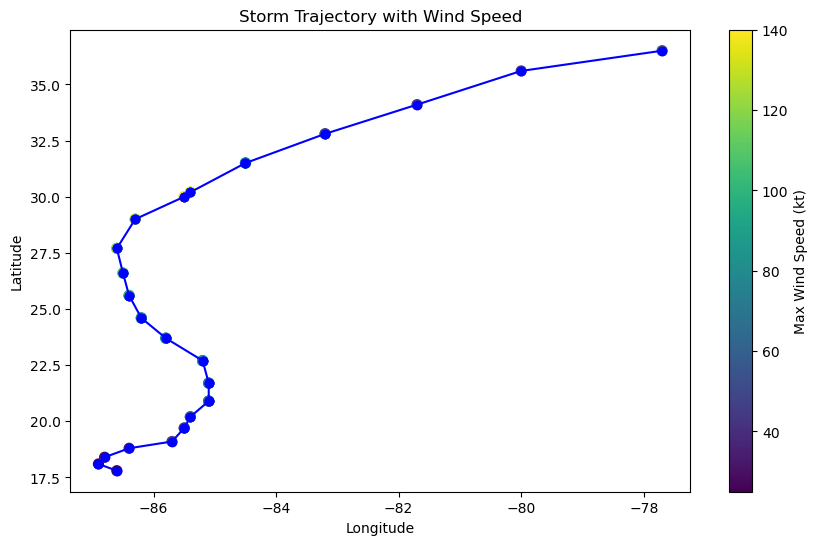

In [29]:
# Okay lets do a plot of the trajectory with the wind speed in color at each point 

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['longitude'], df['latitude'], marker='o', linestyle='-', color='blue', label='Storm Path')
plt.scatter(df['longitude'], df['latitude'], c=df['max_wind_speed_kt'], cmap='viridis', s=50, label='Wind Speed')
plt.colorbar(label='Max Wind Speed (kt)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Storm Trajectory with Wind Speed')

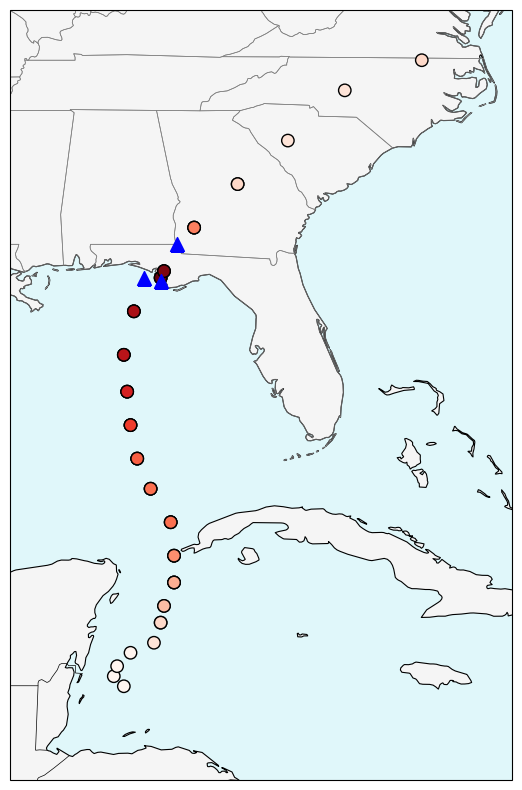

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
    
# 3. Add Map Features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.set_extent([-90, -75, 15, 38], crs=ccrs.PlateCarree())

track_sc = ax.scatter(
        df['longitude'],
        df['latitude'],
        c=df['max_wind_speed_kt'],
        cmap='Reds',
        s=80,
        edgecolor='black',
        vmin=34, vmax=140, # Scale from TS to Cat 5
        label='Storm Track',
        transform=ccrs.PlateCarree(),
        zorder=10 # Draw on top
    )

# Plot test points (houses)
ax.scatter(
    lon2_array,
    lat2_array,
    color='blue',
    marker='^',
    s=100,
    label='Test Points',
    transform=ccrs.PlateCarree(),
    zorder=15 # Draw on top
)

